#📌 Extracão

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

try:
    df_raw = pd.read_json(url)
    print(f"✅ Dados carregados! Total de registros: {len(df_raw)}")
except Exception as e:
    print(f"❌ Erro na extração: {e}")

df_raw.head()

✅ Dados carregados! Total de registros: 7267


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

In [2]:
# Achatando os dicionários para colunas individuais
customer_df = pd.json_normalize(df_raw['customer'])
phone_df = pd.json_normalize(df_raw['phone'])
internet_df = pd.json_normalize(df_raw['internet'])
account_df = pd.json_normalize(df_raw['account'])

# Concatenando tudo em um único DataFrame limpo
df = pd.concat([
    df_raw[['customerID', 'Churn']], 
    customer_df, 
    phone_df, 
    internet_df, 
    account_df
], axis=1)

# Tratamento de tipagem (TotalGasto costuma vir como string)
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

# Desafio Opcional: Contas Diárias
df['Contas_Diarias'] = (df['Charges.Monthly'] / 30).round(2)

print("✅ Dados transformados e normalizados!")
df.head()

✅ Dados transformados e normalizados!


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


#📊 Carga e análise

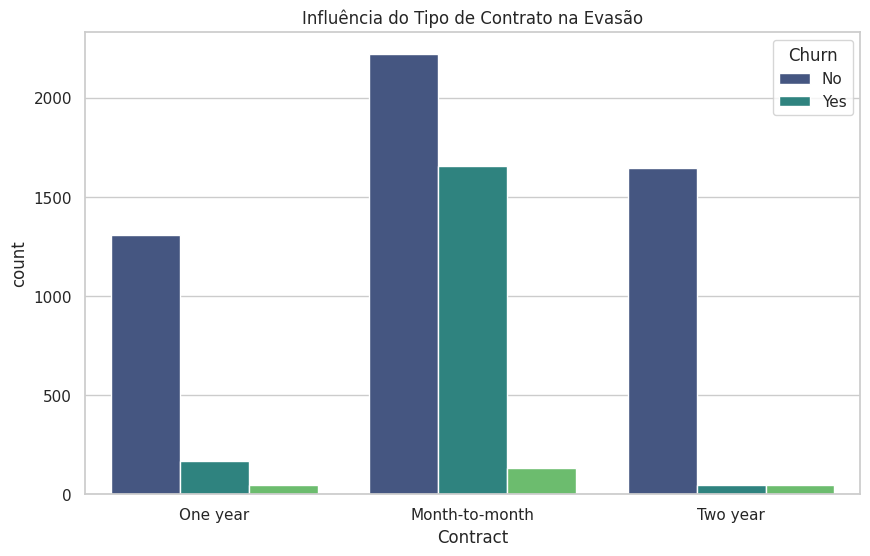

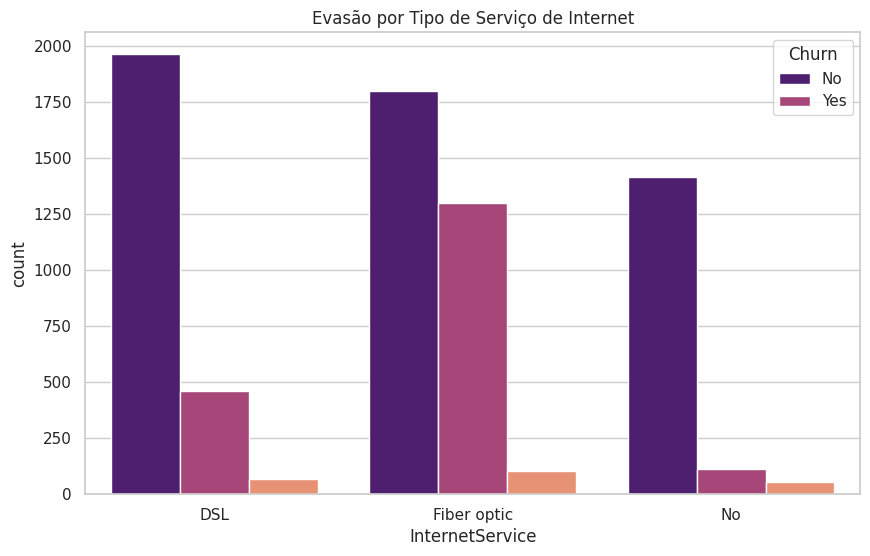

In [3]:
# Configuração visual
sns.set_theme(style="whitegrid")

# Visualização 1: Churn por Tipo de Contrato (Campo crucial no seu dicionário)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Influência do Tipo de Contrato na Evasão')
plt.show()

# Visualização 2: Churn por Serviço de Internet
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='magma')
plt.title('Evasão por Tipo de Serviço de Internet')
plt.show()

#📄Relatorio Final

Com base nos dados normalizados, aqui estão os pontos para conclusão:

Padrão de Contrato: Clientes com contrato "Month-to-month" (mês a mês) têm a maior taxa de evasão.

Fibra Óptica: Note se há uma alta taxa de saída em Fiber optic — isso pode indicar problemas de estabilidade ou preço alto em relação à concorrência.

Ação Recomendada: Criar estratégias de retenção focadas em migrar clientes do plano mensal para planos anuais (One year / Two year).